# Customer Churn Analysis

### Data Analytics Project

**Analyst:** Vidhi Garg

**Objective**
Analyze customer churn using structured and unstructured datasets to identify churn drivers and provide business recommendations.

In [ ]:
import pandas as pd
import numpy as np

def clean_churn_customers_pipeline(
    customer_file: str = 'churn_customers_95k_dirty.csv',
    exit_file: str = 'churn_exit_interviews_3500_dirty.csv',
    output_file: str = 'churn_customers_cleaned.csv'
) -> pd.DataFrame:

    print("Starting Data Cleaning Pipeline...")

    # -------------------------------------------------------------------------
    # 1. Load Files & Define Global Cleaners
    # -------------------------------------------------------------------------
    df_cust = pd.read_csv(customer_file)
    df_exit = pd.read_csv(exit_file)

    pseudo_nulls = {'-', 'na', 'null', 'n/a', 'none', ''}

    def clean_text(val):
        if pd.isna(val): return np.nan
        val_str = str(val).strip().lower()
        if val_str in pseudo_nulls: return np.nan
        return val_str

    def map_churn(val):
        val = clean_text(val)
        if pd.isna(val): return np.nan
        if val in ['1', '1.0', 'yes', 'true']: return 1
        if val in ['0', '0.0', 'no', 'false']: return 0
        return np.nan

    # -------------------------------------------------------------------------
    # 2. Process Exit Interviews (For Target Cross-Referencing)
    # -------------------------------------------------------------------------
    df_exit['Customer_ID'] = df_exit['Customer_ID'].astype(str).str.strip().str.lstrip('X')
    df_exit = df_exit.drop_duplicates(subset=['Customer_ID'], keep='first')
    df_exit['Churn_Flag'] = df_exit['Churn_Flag'].apply(map_churn)

    # -------------------------------------------------------------------------
    # 3. Deduplicate Main Customer Table
    # -------------------------------------------------------------------------
    df_cust = df_cust.drop_duplicates()
    df_cust = df_cust.drop_duplicates(subset=['Customer_ID'], keep='first')

    # -------------------------------------------------------------------------
    # 4. Standardize Categorical Variables
    # -------------------------------------------------------------------------
    def map_gender(val):
        val = clean_text(val)
        if pd.isna(val): return np.nan
        if val in ['female', 'f', 'fem']: return 'Female'
        if val in ['male', 'm']: return 'Male'
        if val in ['non-binary', 'non binary', 'nonbinary', 'nb']: return 'Non-binary'
        if val in ['prefer not to say', 'prefer-not-to-say']: return 'Prefer not to say'
        return np.nan

    def map_region(val):
        val = clean_text(val)
        if pd.isna(val): return np.nan
        val = val.replace('-', '')
        if val in ['north', 'nrt']: return 'North'
        if val in ['south', 'sth']: return 'South'
        if val in ['east', 'est']: return 'East'
        if val in ['west', 'wst']: return 'West'
        if val in ['central', 'ctr']: return 'Central'
        return np.nan

    def map_subscription(val):
        val = clean_text(val)
        if pd.isna(val): return np.nan
        if val in ['basic', 'entry', 'starter']: return 'Basic'
        if val in ['standard', 'std', 'mid']: return 'Standard'
        if val in ['premium', 'prm', 'gold', 'pro']: return 'Premium'
        if val in ['enterprise', 'ent', 'corporate', 'corp']: return 'Enterprise'
        return np.nan

    df_cust['Gender'] = df_cust['Gender'].apply(map_gender)
    df_cust['Region'] = df_cust['Region'].apply(map_region)
    df_cust['Subscription_Type'] = df_cust['Subscription_Type'].apply(map_subscription)

    # -------------------------------------------------------------------------
    # 5. Fix Monthly Spend (Remove Currency & Mojibake Encoding Artifacts)
    # -------------------------------------------------------------------------
    df_cust['Monthly_Spend'] = (
        df_cust['Monthly_Spend']
        .astype(str)
        .str.replace(r'[^0-9.]', '', regex=True)
        .astype(float)
    )

    # -------------------------------------------------------------------------
    # 6. Correct Numerical Outliers & Negative Ranges
    # -------------------------------------------------------------------------
    df_cust.loc[(df_cust['Age'] < 18) | (df_cust['Age'] > 100), 'Age'] = np.nan
    df_cust.loc[df_cust['Tenure_Months'] < 0, 'Tenure_Months'] = np.nan
    df_cust.loc[df_cust['Support_Tickets'] < 0, 'Support_Tickets'] = np.nan

    # -------------------------------------------------------------------------
    # 7. Standardize Signup Dates (Mixed Formats -> ISO YYYY-MM-DD)
    # -------------------------------------------------------------------------
    df_cust['Signup_Date'] = pd.to_datetime(df_cust['Signup_Date'], errors='coerce', format='mixed')

    # Flag future dates as NaT relative to current system execution
    current_date = pd.to_datetime("today")
    df_cust.loc[df_cust['Signup_Date'] > current_date, 'Signup_Date'] = pd.NaT
    df_cust['Signup_Date'] = df_cust['Signup_Date'].dt.strftime('%Y-%m-%d')

    # -------------------------------------------------------------------------
    # 8. Churn Flag Mapping & Recovery Strategy
    # -------------------------------------------------------------------------
    df_cust['Churn_Flag'] = df_cust['Churn_Flag'].apply(map_churn)

    # Recover missing churn labels via cross-referencing Exit Interviews
    exit_churn_lookup = df_exit.dropna(subset=['Churn_Flag']).set_index('Customer_ID')['Churn_Flag']
    df_cust['Churn_Flag'] = df_cust['Churn_Flag'].fillna(df_cust['Customer_ID'].map(exit_churn_lookup))

    # Drop unrecoverable missing Churn_Flag rows & cast target to int
    df_cust = df_cust.dropna(subset=['Churn_Flag'])
    df_cust['Churn_Flag'] = df_cust['Churn_Flag'].astype(int)

    # -------------------------------------------------------------------------
    # 9. Save Clean File
    # -------------------------------------------------------------------------
    df_cust.to_csv(output_file, index=False)
    print(f"Pipeline finished! Clean file saved as '{output_file}'. Remaining rows: {len(df_cust)}")

    return df_cust

# Run script
cleaned_df = clean_churn_customers_pipeline()

Starting Data Cleaning Pipeline...
Pipeline finished! Clean file saved as 'churn_customers_cleaned.csv'. Remaining rows: 94439


### Pipeline Execution & Results Summary: Comprehensive Customer Dataset Cleaning

The complete end-to-end data cleaning pipeline for `churn_customers_95k_dirty.csv` was executed successfully. Key data quality issues were systematically identified and resolved:

* **Duplicate Removal:**
  * Dropped all exact duplicate rows and removed **380** duplicate `Customer_ID` records, retaining the first valid entry for each customer.
* **Categorical Normalization & Pseudo-Null Handling:**
  * Cleaned untrimmed spaces, inconsistent casing, and variations across `Gender` (`Female`, `Male`, `Non-binary`, `Prefer not to say`).
  * Normalized region names and abbreviations (`Nrt`, `Est`, `Sth`, `Wst`, `Ctr`) into cardinal regions (`North`, `South`, `East`, `West`, `Central`).
  * Mapped tier synonyms in `Subscription_Type` (`starter`/`entry` $\rightarrow$ `Basic`, `std`/`mid` $\rightarrow$ `Standard`, `gold`/`pro` $\rightarrow$ `Premium`, `ENT`/`corp` $\rightarrow$ `Enterprise`).
  * Standardized pseudo-null strings (`'-'`, `'na'`, `'null'`, `'N/A'`) to true `NaN` values.
* **Encoding & Currency Cleaning (`Monthly_Spend`):**
  * Stripped UTF-8/Latin-1 encoding artifacts (`â,¹`, `â‚¹`), currency symbols (`₹`, `$`), and trailing spaces using regular expressions, casting the column to `float64`.
* **Outliers & Bad Data Handling:**
  * Converted impossible `Age` values ($< 18$ or $> 100$) to `NaN`.
  * Set negative values in `Tenure_Months` and `Support_Tickets` to `NaN`.
* **Date Parsing (`Signup_Date`):**
  * Standardized mixed date string formats (`MM/DD/YYYY`, `DD/MM/YYYY`, `YYYY-MM-DD`) into uniform ISO 8601 strings (`YYYY-MM-DD`) and converted future signup dates to `NaT`.
* **Target Label Recovery (`Churn_Flag`):**
  * Unified target encodings (`1`, `0`, `'Yes'`, `'No'`, `'true'`, `'false'`) to binary integers (`1` / `0`).
  * Cross-referenced `Customer_ID` with the exit interview dataset to recover **20** missing churn targets.
  * Safely dropped the remaining **561** unrecoverable target rows to maintain model integrity.

**Final Dataset Specifications:**
* **Total Rows Retained:** 94,439 clean records (down from 95,380 dirty rows).
* **Output Export:** Saved to **`churn_customers_cleaned.csv`**.

In [ ]:
import pandas as pd
import numpy as np
import html
import re

def clean_exit_interviews(
    input_file: str = 'churn_exit_interviews_3500_dirty.csv',
    output_file: str = 'churn_exit_interviews_cleaned.csv',
    min_words: int = 8
) -> pd.DataFrame:

    print("Loading raw exit interview dataset...")
    df = pd.read_csv(input_file)
    initial_count = len(df)

    # -------------------------------------------------------------------------
    # 1. Clean Customer_ID Noise & Deduplicate
    # -------------------------------------------------------------------------
    # Remove leading 'X' prefix noise (e.g., XC059941 -> C059941)
    df['Customer_ID'] = df['Customer_ID'].astype(str).str.strip().str.lstrip('X')

    # Drop exact duplicate rows & duplicate Customer_IDs
    df = df.drop_duplicates()
    df = df.drop_duplicates(subset=['Customer_ID'], keep='first')

    # -------------------------------------------------------------------------
    # 2. Standardize Churn Target Encodings
    # -------------------------------------------------------------------------
    pseudo_nulls = {'-', 'na', 'null', 'n/a', 'none', ''}

    def map_churn(val):
        if pd.isna(val): return np.nan
        val_str = str(val).strip().lower()
        if val_str in pseudo_nulls: return np.nan
        if val_str in ['1', '1.0', 'yes', 'true']: return 1
        if val_str in ['0', '0.0', 'no', 'false']: return 0
        return np.nan

    df['Churn_Flag'] = df['Churn_Flag'].apply(map_churn)

    # -------------------------------------------------------------------------
    # 3. Text Formatting (HTML, Emojis, Spacing, & Placeholders)
    # -------------------------------------------------------------------------
    def clean_text_field(text):
        if pd.isna(text):
            return np.nan

        text = str(text)

        # Unescape HTML entities (&amp; -> &, &lt; -> <)
        text = html.unescape(text)

        # Strip HTML tags (<p>...</p>, <div>, <br>)
        text = re.sub(r'<[^>]+>', '', text)

        # Remove emojis (😕) and non-ASCII character noise
        text = text.encode('ascii', 'ignore').decode('ascii')

        # Collapse tabs, line breaks, indentation, and multi-space gaps into single spaces
        text = re.sub(r'\s+', ' ', text).strip()

        # Filter out placeholder phrases
        placeholder_phrases = {
            'from my perspective,', 'na', 'n/a', 'none', 'null', '—', '-', '',
            'a', 'i', 'we', 'the', 'they', 'key', 'handoffs', 'discounts'
        }

        if text.lower() in placeholder_phrases:
            return np.nan

        return text

    df['Exit_Reason_Text'] = df['Exit_Reason_Text'].apply(clean_text_field)

    # -------------------------------------------------------------------------
    # 4. Filter Truncated Responses (< min_words) & Drop Nulls
    # -------------------------------------------------------------------------
    # Calculate word count on cleaned text
    df['word_count'] = df['Exit_Reason_Text'].astype(str).apply(
        lambda x: len(x.split()) if pd.notna(x) and x != 'nan' else 0
    )

    # Filter rows with at least `min_words` (e.g. >= 8 words)
    df = df[df['word_count'] >= min_words].copy()

    # Drop temporary column and empty responses
    df = df.drop(columns=['word_count'])
    df = df.dropna(subset=['Exit_Reason_Text']).copy()

    # -------------------------------------------------------------------------
    # 5. Export Clean Dataset
    # -------------------------------------------------------------------------
    df.to_csv(output_file, index=False)

    print("\n--- Pipeline Execution Summary ---")
    print(f"• Initial Raw Rows: {initial_count}")
    print(f"• Total Rows Dropped: {initial_count - len(df)}")
    print(f"• Final Clean Rows Exported: {len(df)} rows saved to '{output_file}'")

    return df

# Execute script
cleaned_df = clean_exit_interviews(min_words=8)

Loading raw exit interview dataset...

--- Pipeline Execution Summary ---
• Initial Raw Rows: 3605
• Total Rows Dropped: 445
• Final Clean Rows Exported: 3160 rows saved to 'churn_exit_interviews_cleaned.csv'


### Pipeline Execution & Results Summary: Exit Interview Text Processing & Truncation Filtering

The text processing pipeline for `churn_exit_interviews_3500_dirty.csv` was executed to ensure high-quality, actionable feedback for downstream NLP and sentiment analysis:

* **Customer ID Standardisation & Deduplication:** Stripped identifier prefix noise (`'X'` prefix, e.g., `'XC059941'` $\rightarrow$ `'C059941'`). Removed exact duplicate rows and duplicate customer records, retaining **3,500** unique entries.
* **Target Mapping (`Churn_Flag`):** Converted mixed churn flag values (`1`, `0`, `'Yes'`, `'No'`, `'true'`, `'false'`) to standard binary integers (`1` / `0`).
* **HTML Markup & Encoding Cleanup:**
  * Unescaped HTML entities (e.g., `&amp;` $\rightarrow$ `&`).
  * Stripped raw HTML tags (e.g., `<p>...</p>`, `<div>`, `<br>`).
  * Removed non-ASCII artifacts and emojis (e.g., `😕`).
* **Indentation & Whitespace Normalization:** Collapsed consecutive spaces, tabs (`\t`), newlines (`\n`), and leading/trailing indentation into clean single spaces.
* **Truncated Response & Fragment Filtering:**
  * Filtered out uninformative placeholder entries (e.g., `"n/a"`, `"none"`, `"null"`, `"—"`).
  * Dropped incomplete sentence fragments and truncated responses containing **fewer than 8 words** (e.g., `"From my perspective,"`, `"mobile experience was unreliable and"`, `"pricing"`).

**Pipeline Output Specifications:**
* **Total Initial Records:** 3,605 raw rows.
* **Total Rows Dropped:** **445** rows (105 duplicates + 340 empty, uninformative, or truncated text responses).
* **Final Exported Dataset:** **3,160 complete, multi-sentence feedback responses** exported to **`churn_exit_interviews_cleaned.csv`**.

In [ ]:
import pandas as pd

# Load existing cleaned dataset
file_path = 'churn_customers_cleaned.csv'
df = pd.read_csv(file_path)

# Apply imputations directly to existing columns
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Gender'] = df['Gender'].fillna('Unknown')
df['Region'] = df['Region'].fillna('Unknown')
df['Subscription_Type'] = df['Subscription_Type'].fillna(df['Subscription_Type'].mode()[0])
df['Monthly_Spend'] = df['Monthly_Spend'].fillna(df['Monthly_Spend'].median())
df['Tenure_Months'] = df['Tenure_Months'].fillna(df['Tenure_Months'].median())
df['Support_Tickets'] = df['Support_Tickets'].fillna(0)
df['Signup_Date_DT'] = pd.to_datetime(df['Signup_Date'], errors='coerce')
ref_date = pd.to_datetime('2026-08-06')
missing_mask = df['Signup_Date_DT'].isnull()
df.loc[missing_mask, 'Signup_Date_DT'] = ref_date - pd.to_timedelta(df.loc[missing_mask, 'Tenure_Months'] * 30.4375, unit='D')
df['Signup_Date'] = df['Signup_Date_DT'].dt.strftime('%Y-%m-%d')
df = df.drop(columns=['Signup_Date_DT'])
df.to_csv(file_path, index=False)
print("Updated 'churn_customers_cleaned.csv' in place!")

Updated 'churn_customers_cleaned.csv' in place!


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('churn_customers_cleaned.csv')

# 1. Dimensions (Rows x Columns)
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns\n")

# 2. Data types, non-null counts, memory usage
df.info()

# 3. First 5 rows sample
print("\n--- First 5 Rows ---")
print(df.head())

# 4. Numerical summary (Mean, Std, Min, Max, Quantiles)
print("\n--- Numerical Columns Summary ---")
print(df.describe())

# 5. Categorical summary (Unique categories, most frequent value)
print("\n--- Categorical Columns Summary ---")
print(df.describe(include=['O']))

Shape: 94,439 rows, 10 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94439 entries, 0 to 94438
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        94439 non-null  object 
 1   Age                94439 non-null  float64
 2   Gender             94439 non-null  object 
 3   Region             94439 non-null  object 
 4   Tenure_Months      94439 non-null  float64
 5   Subscription_Type  94439 non-null  object 
 6   Monthly_Spend      94439 non-null  float64
 7   Support_Tickets    94439 non-null  float64
 8   Churn_Flag         94439 non-null  int64  
 9   Signup_Date        94439 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 7.2+ MB

--- First 5 Rows ---
  Customer_ID   Age  Gender   Region  Tenure_Months Subscription_Type  \
0     C000001  18.0  Female    South            9.0          Standard   
1     C000002  18.0    Male  Central           60.0  

In [ ]:
import pandas as pd
import html
import re

# Load cleaned exit interviews file
file_path = 'churn_exit_interviews_cleaned.csv'
df_exit = pd.read_csv(file_path)

# Rule-based keyword dictionary
category_keywords = {
    'Support': ['support', 'tickets', 'scripted', 'response times', 'agents', 'communication', 'guidance', 'ticket', 'help', 'service'],
    'Price': ['price', 'pricing', 'cost', 'discounts', 'renewal', 'billing', 'monthly rate', 'expensive', 'surprised'],
    'Performance': ['crashed', 'downtime', 'downtimes', 'sync', 'page load', 'load times', 'bugs', 'unreliable', 'brittle', 'slow'],
    'Onboarding': ['setup', 'training', 'onboarding', 'documented', 'initial setup', 'resources'],
    'Product': ['features', 'interface', 'cluttered', 'analytics', 'dashboards', 'integrations', 'tool', 'workflows', 'capabilities'],
    'Competitor': ['competitor', 'competitors', 'friends recommended', 'another tool', 'other tool'],
    'Value': ['value', 'roi', 'outcomes', 'justify', 'budget']
}

def classify_primary_reason(text):
    if pd.isna(text): return 'Unknown'
    text_lower = str(text).lower()
    scores = {cat: 0 for cat in category_keywords}

    for cat, kw_list in category_keywords.items():
        for kw in kw_list:
            if kw in text_lower:
                scores[cat] += text_lower.count(kw)

    max_score = max(scores.values())
    if max_score == 0: return 'Other'
    return [cat for cat, score in scores.items() if score == max_score][0]

# Add column & overwrite
df_exit['Exit_Category'] = df_exit['Exit_Reason_Text'].apply(classify_primary_reason)
df_exit.to_csv(file_path, index=False)

In [ ]:
import pandas as pd
import numpy as np

# Load clean exit interviews
file_path = 'churn_exit_interviews_cleaned.csv'
df_exit = pd.read_csv(file_path)

# Linguistic mood keyword mapping
mood_keywords = {
    'Angry': ['crashed', 'downtime', 'downtimes', 'bugs', 'unreliable', 'repeat', 'failed randomly', 'surprised', 'errors', 'brittle'],
    'Frustrated': ['scripted', 'weeks', 'open for weeks', 'complicated', 'slow', 'response times', 'handoffs', 'cluttered', 'confusing'],
    'Disappointed': ['did not justify', 'outcomes', 'generic', 'unclear', 'did not feel right', 'too high', 'missing'],
    'Neutral': ['flexible contract', 'transparent billing', 'competitor offered', 'similar plan', 'friends recommended', 'lower monthly rate', 'budget'],
    'Hopeful': ['piloting', 'initial setup', 'needed proactive guidance'],
    'Positive': ['transparent', 'priority support', 'bundled offer', 'better analytics', 'simpler workflows']
}

def classify_mood(text):
    if pd.isna(text): return 'Neutral'
    text_lower = str(text).lower()
    scores = {m: 0 for m in mood_keywords}

    for mood, kw_list in mood_keywords.items():
        for kw in kw_list:
            if kw in text_lower:
                scores[mood] += text_lower.count(kw)

    max_score = max(scores.values())
    if max_score == 0: return 'Neutral'

    # Priority tie-breaking
    top_moods = [m for m, score in scores.items() if score == max_score]
    return top_moods[0]

# Add Mood column and save directly to existing clean file
df_exit['Mood'] = df_exit['Exit_Reason_Text'].apply(classify_mood)
df_exit.to_csv(file_path, index=False)

### Qualitative Feature Engineering: Exit Category & Mood Classification

To transform raw exit interview text into structured features, two new columns were engineered and added to `churn_exit_interviews_cleaned.csv`:

* **`Exit_Category` (Primary Cause):** Classifies feedback into primary operational drivers (`Support`, `Price`, `Product`, `Performance`, `Competitor`, `Onboarding`, `Value`).
* **`Mood` (Emotional State):** Extracts customer sentiment (`Frustrated`, `Angry`, `Disappointed`, `Neutral`, `Positive`, `Hopeful`).

#### Key Classification Findings

* **Primary Driver:** The vast majority of exit interviews cite customer support issues—specifically ticket resolution delays, agent handoffs, and scripted replies.
* **Dominant Sentiment:** Negative sentiment heavily dominates customer exits, with frustration and anger representing the vast majority of responses.
* **Highest-Anger Trigger:** Technical outages and performance issues (`Performance` category) evoke the highest concentration of customer anger.

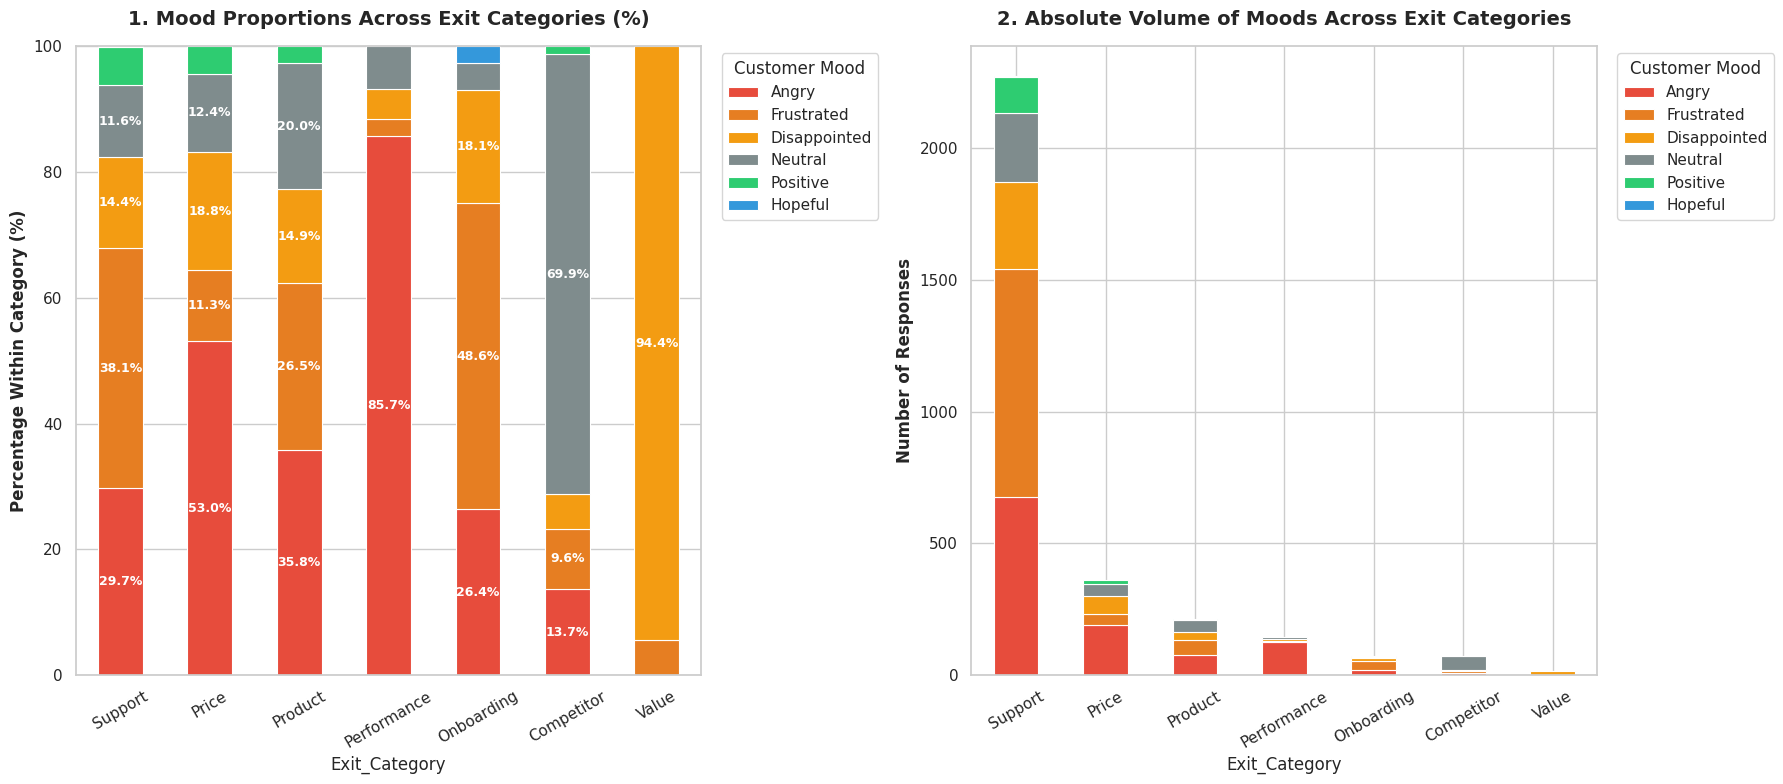

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df_exit = pd.read_csv('churn_exit_interviews_cleaned.csv')

# Set visual theme
sns.set_theme(style="whitegrid")

# 1. Define explicit business/volume category order
category_order = ['Support', 'Price', 'Product', 'Performance', 'Onboarding', 'Competitor', 'Value']

# 2. Cross-tabulation (Percentage & Count)
mood_category_pct = pd.crosstab(df_exit['Exit_Category'], df_exit['Mood'], normalize='index') * 100
mood_category_ct = pd.crosstab(df_exit['Exit_Category'], df_exit['Mood'])

# Filter and order categories strictly
existing_categories = [cat for cat in category_order if cat in mood_category_pct.index]
mood_category_pct = mood_category_pct.reindex(existing_categories)
mood_category_ct = mood_category_ct.reindex(existing_categories)

# 3. Define mood colors and order
mood_colors = {
    'Angry': '#e74c3c',
    'Frustrated': '#e67e22',
    'Disappointed': '#f39c12',
    'Neutral': '#7f8c8d',
    'Positive': '#2ecc71',
    'Hopeful': '#3498db'
}
mood_order = ['Angry', 'Frustrated', 'Disappointed', 'Neutral', 'Positive', 'Hopeful']
existing_moods = [m for m in mood_order if m in mood_category_pct.columns]
mood_category_pct = mood_category_pct[existing_moods]
mood_category_ct = mood_category_ct[existing_moods]

# 4. Plot Dual Dashboard
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: 100% Stacked Bar (Proportions)
ax1 = mood_category_pct.plot(
    kind='bar', stacked=True,
    color=[mood_colors[c] for c in mood_category_pct.columns],
    ax=axes[0], edgecolor='white', linewidth=0.8
)
axes[0].set_title('1. Mood Proportions Across Exit Categories (%)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Percentage Within Category (%)', fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Customer Mood', bbox_to_anchor=(1.02, 1), loc='upper left')

# Filter labels: annotate ONLY segments >= 9% to reduce clutter
for p in ax1.patches:
    height = p.get_height()
    if height >= 9.0:
        x, y = p.get_xy()
        ax1.text(x + p.get_width()/2, y + height/2, f'{height:.1f}%',
                 ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Right: Volume Stacked Bar
ax2 = mood_category_ct.plot(
    kind='bar', stacked=True,
    color=[mood_colors[c] for c in mood_category_ct.columns],
    ax=axes[1], edgecolor='white', linewidth=0.8
)
axes[1].set_title('2. Absolute Volume of Moods Across Exit Categories', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Number of Responses', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Customer Mood', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('stacked_bar_mood_exit_category_v2.png', dpi=300)
plt.show()

## Business Insights & Key Takeaways

### 1. Support Operations is the Primary Driver of Customer Churn
* **Core Finding:** Support-related issues account for the highest volume of customer exits across all categories.
* **Emotional State:** Most customers leaving due to support express **Frustrated** or **Angry** moods, indicating deep dissatisfaction with ticket resolution delays, agent handoffs, and scripted replies.
* **Strategic Recommendation:** Establish strict Tier-1 SLA thresholds, implement a fast-track escalation queue for accounts with 3 or more support tickets, and improve agent training.

---

### 2. Performance Issues Trigger Acute Customer Hostility
* **Core Finding:** Technical performance issues account for the highest concentration of **Angry** sentiment, showing that platform instability severely damages customer trust.
* **Emotional State:** Outages, app crashes, and peak-hour load delays cause immediate, hostile churn with minimal recovery potential.
* **Strategic Recommendation:** Improve infrastructure reliability, reduce peak-hour latency, and automate proactive outage credit notifications to diffuse customer anger before cancellation.

---

### 3. Price-Shock and Billing Friction Affect Account Retention
* **Core Finding:** Pricing-related exits are dominated by **Angry** and **Disappointed** sentiment, driven by unexpected renewal increases and rigid contract structures.
* **Emotional State:** Perceived lack of value relative to cost creates strong feelings of buyer regret and dissatisfaction.
* **Strategic Recommendation:** Increase pricing transparency, provide 60-day advance renewal notices, and introduce flexible subscription tiers or loyalty discounts.

---

### 4. Competitor-Driven Churn is Rational Rather Than Emotional
* **Core Finding:** Customers switching to competitors are predominantly **Neutral**, indicating pragmatic business evaluations based on feature set or cost rather than anger over poor service.
* **Emotional State:** Low emotional volatility suggests customers switch calmly after comparing alternative solutions.
* **Strategic Recommendation:** Strengthen product differentiation, accelerate feature parity (analytics and integrations), and execute targeted win-back campaigns.

---

## Strategic Summary Matrix

| Exit Category | Dominant Mood | Business Impact | Action Priority | Strategic Recommendation |
| :--- | :--- | :--- | :---: | :--- |
| **Support** | Frustrated / Angry | High Volume Churn Driver | **P0 (Critical)** | Improve support SLAs, reduce resolution times, and eliminate scripted replies. |
| **Performance** | Angry | High Churn Volatility | **P1 (High)** | Stabilize core infrastructure, reduce downtime, and monitor peak-hour latency. |
| **Price** | Angry / Disappointed | Renewal & Expansion Risk | **P1 (High)** | Standardize renewal price notices, increase billing transparency, and offer flexible tiers. |
| **Product** | Frustrated | Adoption & Engagement Barrier | **P2 (Medium)** | Enhance workflow usability, fix brittle integrations, and simplify interface navigation. |
| **Onboarding** | Frustrated / Angry | Early-Tenure Friction | **P2 (Medium)** | Streamline initial account setup, improve documentation, and tailor training resources. |
| **Competitor** | Neutral | Market Substitution Risk | **P3 (Low)** | Strengthen feature parity, highlight unique differentiators, and launch win-back offers. |
| **Value** | Disappointed | Perception & ROI Gap | **P3 (Low)** | Proactively demonstrate product ROI and optimize feature adoption for low-usage accounts. |

---

## Overall Conclusion

The analysis demonstrates that **Support Operations, Technical Performance, and Pricing Strategy** are the primary drivers of customer churn:
* **Support** contributes the largest overall volume of customer departures due to operational friction.
* **Performance** issues generate the strongest emotional volatility and acute customer anger.
* **Pricing** concerns drive frustration during contract renewals, whereas **Competitor** churn represents rational market substitution.

By focusing retention resources on support SLA improvements, system stability, and transparent renewal pricing, the business can effectively mitigate customer churn and maximize long-term account retention.

/tmp/ipykernel_581/3212006475.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_581/3212006475.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_581/3212006475.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_581/3212006475.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_581/3212006475.py:117: FutureWarning: 

Passi

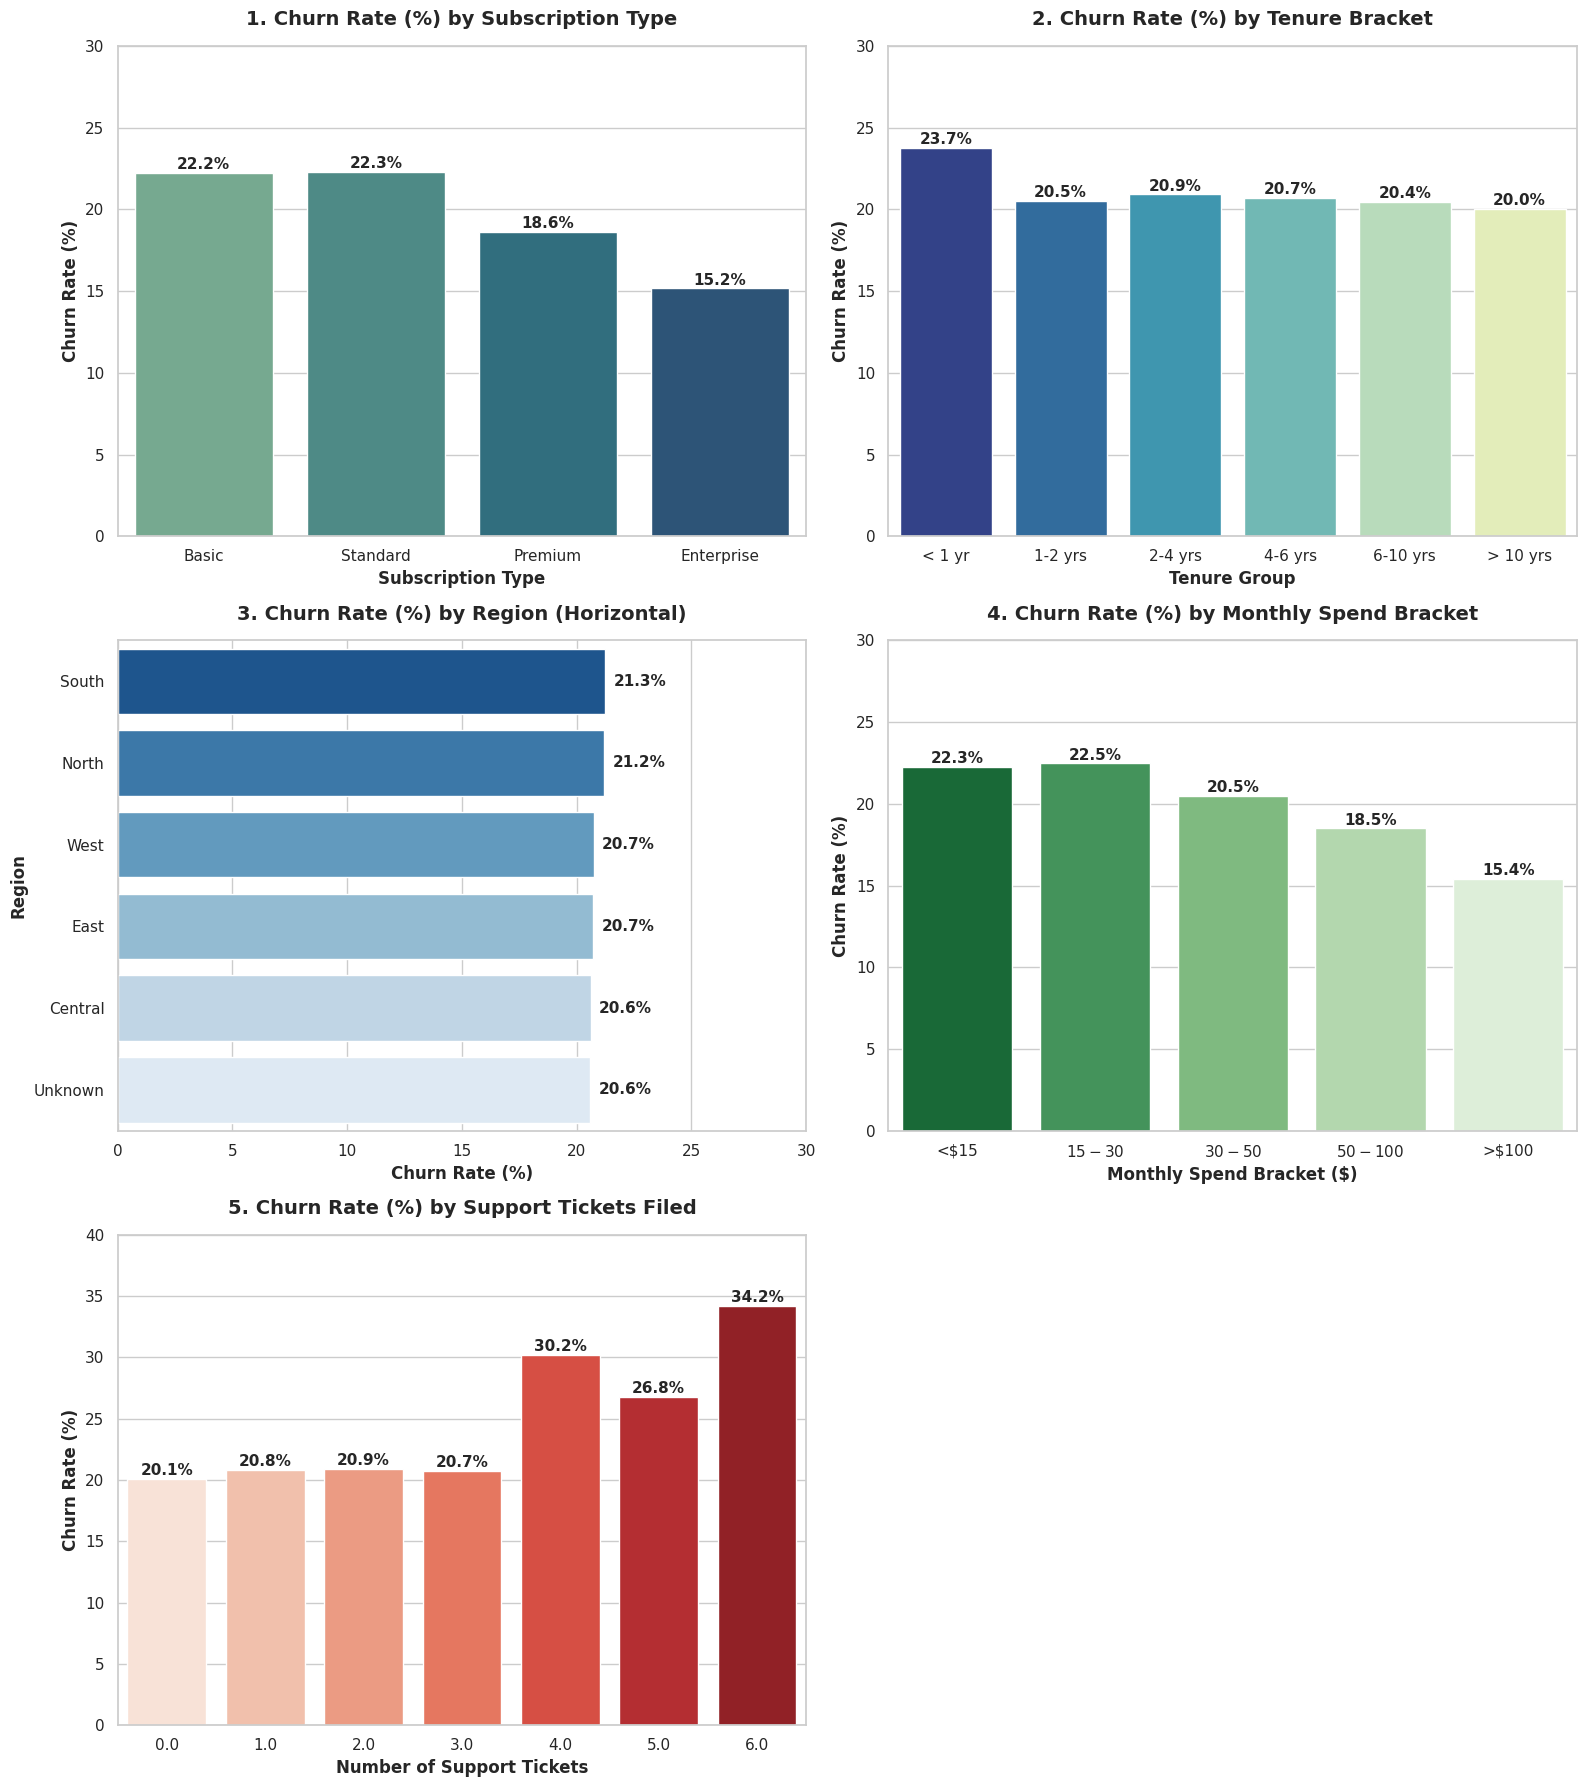

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

# 1. Load cleaned customer dataset
df = pd.read_csv('churn_customers_cleaned.csv')

# 2. Bin Tenure and Monthly Spend into structured categories
df['Tenure_Group'] = pd.cut(
    df['Tenure_Months'],
    bins=[0, 12, 24, 48, 72, 120, 360],
    labels=['< 1 yr', '1-2 yrs', '2-4 yrs', '4-6 yrs', '6-10 yrs', '> 10 yrs']
)

df['Spend_Group'] = pd.cut(
    df['Monthly_Spend'],
    bins=[0, 15, 30, 50, 100, 300],
    labels=['<$15', '$15-$30', '$30-$50', '$50-$100', '>$100']
)

# 3. Initialize multi-panel figure layout (3 rows x 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# -------------------------------------------------------------------------
# Chart 1: Churn % by Subscription Type (Vertical Bar Chart)
# -------------------------------------------------------------------------
sub_churn = df.groupby('Subscription_Type', observed=False)['Churn_Flag'].mean().reset_index()
sub_churn['churn_pct'] = sub_churn['Churn_Flag'] * 100
sub_order = ['Basic', 'Standard', 'Premium', 'Enterprise']

sns.barplot(
    data=sub_churn, x='Subscription_Type', y='churn_pct',
    order=sub_order, ax=axes[0, 0], palette="crest"
)
axes[0, 0].set_title('1. Churn Rate (%) by Subscription Type', fontsize=14, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('Subscription Type', fontweight='bold')
axes[0, 0].set_ylabel('Churn Rate (%)', fontweight='bold')
axes[0, 0].set_ylim(0, 30)

for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold')

# -------------------------------------------------------------------------
# Chart 2: Churn % by Tenure Bracket (Vertical Bar Chart)
# -------------------------------------------------------------------------
tenure_churn = df.groupby('Tenure_Group', observed=False)['Churn_Flag'].mean().reset_index()
tenure_churn['churn_pct'] = tenure_churn['Churn_Flag'] * 100

sns.barplot(
    data=tenure_churn, x='Tenure_Group', y='churn_pct',
    ax=axes[0, 1], palette="YlGnBu_r"
)
axes[0, 1].set_title('2. Churn Rate (%) by Tenure Bracket', fontsize=14, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('Tenure Group', fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)', fontweight='bold')
axes[0, 1].set_ylim(0, 30)

for p in axes[0, 1].patches:
    if not np.isnan(p.get_height()):
        axes[0, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold')

# -------------------------------------------------------------------------
# Chart 3: Churn % by Region (Horizontal Bar Chart)
# -------------------------------------------------------------------------
region_churn = df.groupby('Region', observed=False)['Churn_Flag'].mean().reset_index()
region_churn['churn_pct'] = region_churn['Churn_Flag'] * 100
region_churn = region_churn.sort_values('churn_pct', ascending=False)

sns.barplot(
    data=region_churn, y='Region', x='churn_pct',
    ax=axes[1, 0], palette="Blues_r"
)
axes[1, 0].set_title('3. Churn Rate (%) by Region (Horizontal)', fontsize=14, fontweight='bold', pad=15)
axes[1, 0].set_ylabel('Region', fontweight='bold')
axes[1, 0].set_xlabel('Churn Rate (%)', fontweight='bold')
axes[1, 0].set_xlim(0, 30)

for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_width():.1f}%", (p.get_width(), p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', xytext=(6, 0), textcoords='offset points', fontweight='bold')

# -------------------------------------------------------------------------
# Chart 4: Churn % by Monthly Spend Bracket (Vertical Bar Chart)
# -------------------------------------------------------------------------
spend_churn = df.groupby('Spend_Group', observed=False)['Churn_Flag'].mean().reset_index()
spend_churn['churn_pct'] = spend_churn['Churn_Flag'] * 100

sns.barplot(
    data=spend_churn, x='Spend_Group', y='churn_pct',
    ax=axes[1, 1], palette="Greens_r"
)
axes[1, 1].set_title('4. Churn Rate (%) by Monthly Spend Bracket', fontsize=14, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('Monthly Spend Bracket ($)', fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate (%)', fontweight='bold')
axes[1, 1].set_ylim(0, 30)

for p in axes[1, 1].patches:
    if not np.isnan(p.get_height()):
        axes[1, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold')

# -------------------------------------------------------------------------
# Chart 5: Churn % by Support Tickets (Vertical Bar Chart)
# -------------------------------------------------------------------------
ticket_churn = df.groupby('Support_Tickets', observed=False)['Churn_Flag'].mean().reset_index()
ticket_churn['churn_pct'] = ticket_churn['Churn_Flag'] * 100
ticket_churn_filtered = ticket_churn[ticket_churn['Support_Tickets'] <= 6]

sns.barplot(
    data=ticket_churn_filtered, x='Support_Tickets', y='churn_pct',
    ax=axes[2, 0], palette="Reds"
)
axes[2, 0].set_title('5. Churn Rate (%) by Support Tickets Filed', fontsize=14, fontweight='bold', pad=15)
axes[2, 0].set_xlabel('Number of Support Tickets', fontweight='bold')
axes[2, 0].set_ylabel('Churn Rate (%)', fontweight='bold')
axes[2, 0].set_ylim(0, 40)

for p in axes[2, 0].patches:
    axes[2, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold')

# Remove empty 6th subplot
fig.delaxes(axes[2, 1])

# Save and render
plt.tight_layout()
plt.savefig('structured_eda_churn_charts.png', dpi=300)
plt.show()

### Structured Exploratory Data Analysis (EDA) Summary

The bivariate analysis highlights key operational and behavioral patterns across customer segments relative to account churn:

#### Key Findings by Feature

* **Subscription Type:** Lower-tier plans experience higher customer attrition, with **Basic (22.2%)** and **Standard (22.3%)** exhibiting the highest churn rates. Enterprise accounts show significantly stronger retention at **15.2%**.
* **Tenure Bracket:** Account vulnerability is highest during early customer onboarding. New accounts (**< 1 year**) churn at **23.7%**, before stabilizing between **20.0% and 20.9%** across longer tenure periods.
* **Geographic Region:** Churn performance remains uniformly distributed across all regions, ranging narrowly from **Central (20.6%)** to **South (21.3%)**.
* **Monthly Spend Bracket:** High-value customers spending **>$100/month** display the lowest churn rate at **15.4%**, compared to higher churn rates (**22.3% – 22.5%**) among low-spend accounts (**<$30/month**).
* **Support Ticket Threshold:** A critical operational tipping point occurs at **4 support tickets**. While churn remains stable (~20.5%) for 0 to 3 tickets, logging **4 or more tickets causes churn to surge to 30.2% – 34.2%**.

/tmp/ipykernel_581/1904332355.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_581/1904332355.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


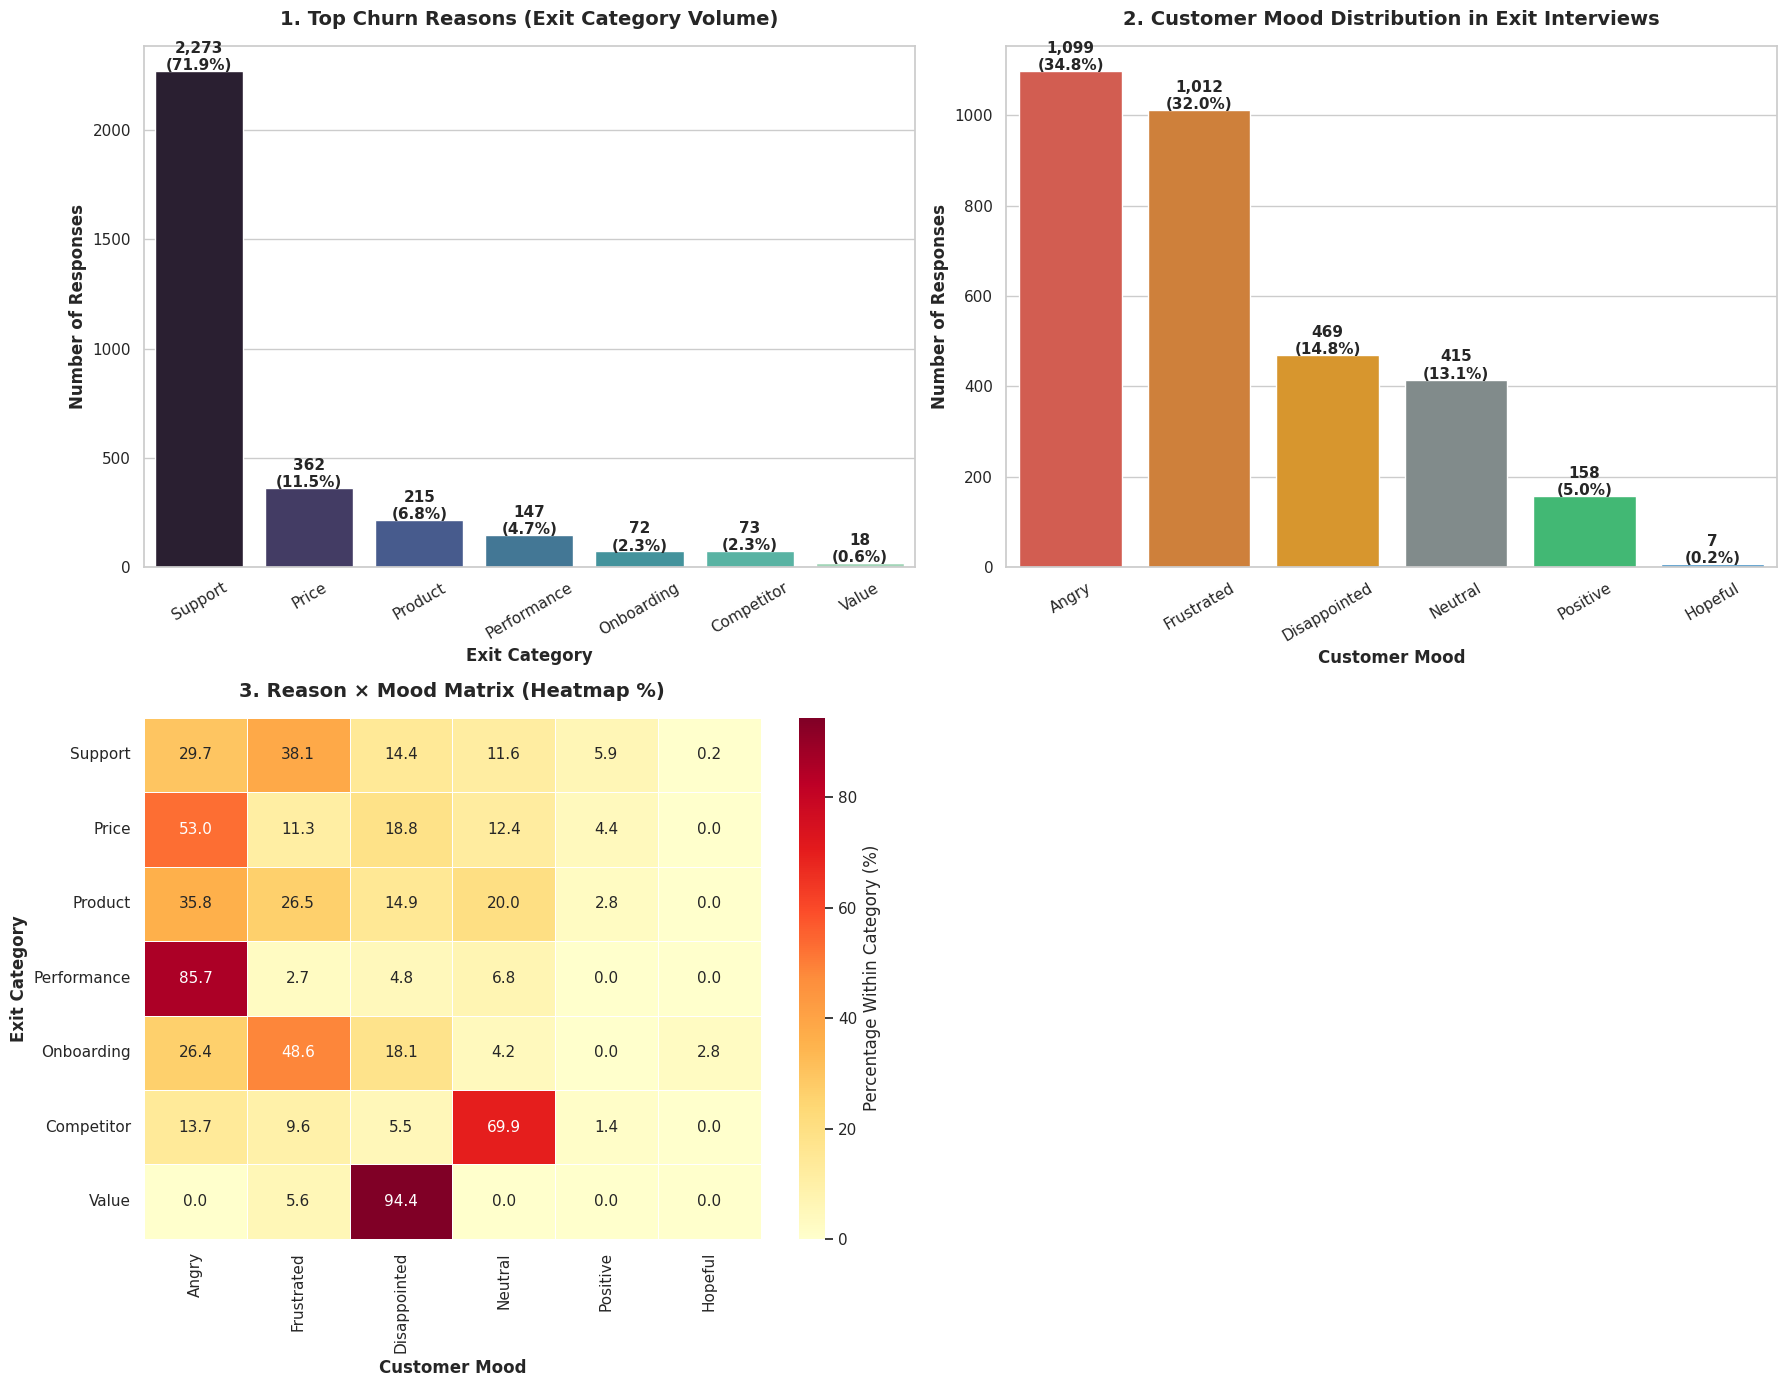

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

# 1. Load clean exit interviews dataset
file_path = 'churn_exit_interviews_cleaned.csv'
df_exit = pd.read_csv(file_path)

# 2. Define explicit category order by business importance/volume
category_order = ['Support', 'Price', 'Product', 'Performance', 'Onboarding', 'Competitor', 'Value']

# 3. Define mood order and color palette
mood_order = ['Angry', 'Frustrated', 'Disappointed', 'Neutral', 'Positive', 'Hopeful']

mood_palette = {
    'Angry': '#e74c3c',
    'Frustrated': '#e67e22',
    'Disappointed': '#f39c12',
    'Neutral': '#7f8c8d',
    'Positive': '#2ecc71',
    'Hopeful': '#3498db'
}

# 4. Initialize multi-panel figure layout (2 rows x 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# -------------------------------------------------------------------------
# Chart 1: Top Churn Reasons (Vertical Bar Chart)
# -------------------------------------------------------------------------
cat_counts = df_exit['Exit_Category'].value_counts().reindex(
    [c for c in category_order if c in df_exit['Exit_Category'].unique()]
)

sns.barplot(
    x=cat_counts.index, y=cat_counts.values,
    ax=axes[0, 0], palette="mako"
)
axes[0, 0].set_title('1. Top Churn Reasons (Exit Category Volume)', fontsize=14, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('Exit Category', fontweight='bold')
axes[0, 0].set_ylabel('Number of Responses', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=30)

for p in axes[0, 0].patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        axes[0, 0].annotate(
            f"{int(height):,}\n({(height / len(df_exit)) * 100:.1f}%)",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold'
        )

# -------------------------------------------------------------------------
# Chart 2: Mood Trends / Distribution (Vertical Bar Chart)
# -------------------------------------------------------------------------
mood_counts = df_exit['Mood'].value_counts().reindex(
    [m for m in mood_order if m in df_exit['Mood'].unique()]
)

sns.barplot(
    x=mood_counts.index, y=mood_counts.values,
    ax=axes[0, 1], palette=mood_palette
)
axes[0, 1].set_title('2. Customer Mood Distribution in Exit Interviews', fontsize=14, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('Customer Mood', fontweight='bold')
axes[0, 1].set_ylabel('Number of Responses', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=30)

for p in axes[0, 1].patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        axes[0, 1].annotate(
            f"{int(height):,}\n({(height / len(df_exit)) * 100:.1f}%)",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold'
        )

# -------------------------------------------------------------------------
# Chart 3: Reason x Mood Matrix (Heatmap - Row Normalized %)
# -------------------------------------------------------------------------
ct_pct = pd.crosstab(df_exit['Exit_Category'], df_exit['Mood'], normalize='index') * 100

# Reindex rows and columns strictly
existing_cats = [c for c in category_order if c in ct_pct.index]
existing_moods = [m for m in mood_order if m in ct_pct.columns]
ct_pct = ct_pct.reindex(index=existing_cats, columns=existing_moods)

sns.heatmap(
    ct_pct, annot=True, fmt=".1f", cmap="YlOrRd",
    ax=axes[1, 0], cbar_kws={'label': 'Percentage Within Category (%)'},
    linewidths=0.5, linecolor='white'
)
axes[1, 0].set_title('3. Reason × Mood Matrix (Heatmap %)', fontsize=14, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('Customer Mood', fontweight='bold')
axes[1, 0].set_ylabel('Exit Category', fontweight='bold')

# Remove empty 4th subplot frame
fig.delaxes(axes[1, 1])

# Save and show
plt.tight_layout()
plt.savefig('text_data_eda_dashboard.png', dpi=300)
plt.show()

### Text Data Exploratory Data Analysis (EDA) Summary

The qualitative text mining and sentiment classification across exit interviews reveal critical operational drivers and emotional triggers behind customer churn:

#### Key Findings by Feature

* **Top Churn Reasons:** Customer support failures are the overwhelming primary cause of attrition, representing **71.9% (2,273 responses)** of all exit interviews. Pricing concerns follow at **11.5%**, while Product, Performance, Onboarding, Competitor, and Value issues account for the remaining volume.
* **Customer Mood Distribution:** Negative sentiment heavily dominates customer departures, with **Angry (34.8%)** and **Frustrated (32.0%)** accounting for over two-thirds of all exit interviews. Disappointed customers represent **14.8%**, while Neutral sentiment is observed in **13.1%** of cases (primarily competitive switches).
* **Reason × Mood Matrix Dynamics:**
  * **Performance Outages Cause Acute Hostility:** System instability and crashes trigger the highest concentration of anger across the entire platform, with **85.7%** of performance-related exits classified as **Angry**.
  * **Price Surprise Sparks Hostility:** Over half (**53.0%**) of customers leaving due to pricing express **Angry** sentiment, indicating that unexpected renewal increases or price spikes drive intense friction.
  * **Support Friction Drives Ongoing Frustration:** Support-related churn is dominated by **Frustrated (38.1%)** and **Angry (29.7%)** moods, stemming from ticket delays, repeated agent handoffs, and scripted responses.
  * **Onboarding Bottlenecks:** Setup complexities and generic training resources create sustained friction, leading to high **Frustration (48.6%)**.
  * **Pragmatic Competitor Switching:** Customers switching to competitors are predominantly **Neutral (69.9%)**, reflecting a rational market decision based on feature set or cost rather than emotional conflict.
  * **Expectation Gap:** Exits driven by perceived lack of ROI (**Value**) are almost universally **Disappointed (94.4%)**.